# Pipeline 5: Donation Impact Attribution

**Explanatory + Data Product Pipeline**  
Connecting donation activity to resident outcomes at safehouses protecting Native American women and girls.

## 1. Business Understanding

Leadership wants to **show donors how their dollars help**. The core question is: can we connect donation activity to measurable improvements in resident health and education outcomes?

**Goal:** "Every $1,000 directed to health services predicts +X improvement in health scores."

### Two Deliverables

| # | Deliverable | Method | Purpose |
|---|-------------|--------|---------|
| 1 | **Explanatory ML model** | statsmodels OLS | Quantify the donation-to-outcome association with statistical rigor (coefficients, CIs, p-values) |
| 2 | **Donor impact report** | Pure data join (no ML inference) | Per-donor attribution showing which safehouses they funded and the outcomes at those safehouses |

### Stakeholders

- **Executive Director** -- uses the OLS results in board presentations and grant applications
- **Donor Relations team** -- uses the impact report to personalize outreach
- **Individual donors** -- see their personalized impact via a React web dashboard
- **Program managers** -- use the model to justify budget allocation across program areas

## 2. Data Acquisition and Preparation

**Join chain:** `donations` -> `donation_allocations` -> `safehouse_monthly_metrics`

Steps:
1. Join `donation_allocations` to `donations` on `donation_id` to get `donation_date`
2. Floor `donation_date` to first of month -> `month_start`
3. Aggregate per `(safehouse_id, month_start)` by program area buckets
4. LEFT JOIN to `safehouse_monthly_metrics` on `(safehouse_id, month_start)`
5. Fill NaN donation columns with 0
6. Create lag features (shift by 1 month within each safehouse group): donations at T -> outcomes at T+1
7. Controls: `active_residents_lag1`, `capacity_utilization_lag1`, `month_of_year`
8. Safehouse fixed effects (one-hot encoding) for OLS

In [1]:
# -- Database connection -------------------------------------------------------
import sys
from pathlib import Path

ROOT = Path.cwd()
for _ in range(8):
    ml_path = ROOT / 'is455' / 'ml-pipelines'
    if ml_path.exists():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'is455' / 'ml-pipelines'))

from utils.db_loader import get_engine, load_table
engine = get_engine()

In [2]:
# ── Resolve project root and load utilities ───────────────────────────────────
ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'is455' / 'ml-pipelines').exists():
        break
    ROOT = ROOT.parent

MLPIPELINES = ROOT / 'is455' / 'ml-pipelines'
sys.path.insert(0, str(MLPIPELINES))

from utils.db_loader import get_engine, load_table
from utils.onnx_exporter import export_to_onnx, verify_onnx

print(f'Project root: {ROOT}')
print(f'ml-pipelines: {MLPIPELINES}')

Project root: /Users/nathanblatter/Desktop/INTEX-II
ml-pipelines: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

In [4]:
# -- Load raw tables -----------------------------------------------------------
donations = load_table(engine, 'donations')
donation_allocations = load_table(engine, 'donation_allocations')
safehouse_monthly_metrics = load_table(engine, 'safehouse_monthly_metrics')
safehouses = load_table(engine, 'safehouses')
supporters = load_table(engine, 'supporters')

print(f'donations:                  {donations.shape}')
print(f'donation_allocations:       {donation_allocations.shape}')
print(f'safehouse_monthly_metrics:  {safehouse_monthly_metrics.shape}')
print(f'safehouses:                 {safehouses.shape}')
print(f'supporters:                 {supporters.shape}')

donations:                  (420, 13)
donation_allocations:       (521, 7)
safehouse_monthly_metrics:  (450, 11)
safehouses:                 (9, 13)
supporters:                 (60, 15)


In [5]:
donations.head(3)

,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.1800,717.1800,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.1500,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.6500,1074.6500,pesos,Campaign support,NaN


In [6]:
donation_allocations.head(3)

,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes
0,1,1,2,Education,717.1800,2025-12-31,None
1,2,2,4,Transport,35.1500,2025-12-02,None
2,3,3,8,Wellbeing,1074.6500,2024-12-02,None


In [7]:
safehouse_monthly_metrics.head(3)

,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,None
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,None
2,3,1,2023-03-01,2023-03-31,10,56.3000,3.0300,1,0,0,None


In [8]:
# -- Step 1: Join allocations to donations to get donation_date ----------------
donations['donation_date'] = pd.to_datetime(donations['donation_date'], errors='coerce')
donation_allocations['amount_allocated'] = pd.to_numeric(
    donation_allocations['amount_allocated'], errors='coerce'
).fillna(0)

alloc = donation_allocations.merge(
    donations[['donation_id', 'donation_date']],
    on='donation_id',
    how='left',
)

# -- Step 2: Floor donation_date to first of month -----------------------------
alloc['month_start'] = alloc['donation_date'].dt.to_period('M').dt.to_timestamp()
print(f'Allocations with donation_date joined: {alloc.shape}')
alloc[['allocation_id', 'donation_id', 'safehouse_id', 'program_area',
       'amount_allocated', 'donation_date', 'month_start']].head(5)

Allocations with donation_date joined: (521, 9)


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,donation_date,month_start
0,1,1,2,Education,717.1800,2025-12-31,2025-12-01
1,2,2,4,Transport,35.1500,2025-12-02,2025-12-01
2,3,3,8,Wellbeing,1074.6500,2024-12-02,2024-12-01
3,4,4,9,Operations,799.8600,2023-09-11,2023-09-01
4,5,5,8,Operations,1177.4100,2023-11-08,2023-11-01


In [9]:
# -- Step 3: Aggregate per (safehouse_id, month_start) by program area ---------
PROGRAM_AREA_MAP = {
    'donation_to_health':     ['Health', 'Wellbeing'],
    'donation_to_education':  ['Education'],
    'donation_to_counseling': ['Counsel', 'Case'],
    'donation_to_operations': ['Operation', 'Admin'],
}

def _area_flag(series, keywords):
    pattern = '|'.join(keywords)
    return series.str.contains(pattern, case=False, na=False)

agg_rows = []
for (sh_id, ms), grp in alloc.groupby(['safehouse_id', 'month_start']):
    row = {'safehouse_id': sh_id, 'month_start': ms}
    for col, keywords in PROGRAM_AREA_MAP.items():
        mask = _area_flag(grp['program_area'], keywords)
        row[col] = grp.loc[mask, 'amount_allocated'].sum()
    row['donation_total'] = grp['amount_allocated'].sum()
    agg_rows.append(row)

don_monthly = pd.DataFrame(agg_rows)
print(f'Monthly donation aggregates: {don_monthly.shape}')
don_monthly.head()

Monthly donation aggregates: (258, 7)


,safehouse_id,month_start,donation_to_health,donation_to_education,donation_to_counseling,donation_to_operations,donation_total
0,1,2023-03-01,0.0000,0.0000,0.0000,990.4800,990.4800
1,1,2023-04-01,0.0000,0.0000,0.0000,794.2700,794.2700
2,1,2023-05-01,283.9900,0.0000,0.0000,0.0000,283.9900
3,1,2023-06-01,1788.9200,21.6700,0.0000,157.9600,2272.0000
4,1,2023-07-01,0.0000,811.7200,0.0000,583.6000,1998.1200


In [10]:
# -- Step 4: LEFT JOIN to safehouse_monthly_metrics ----------------------------
metrics = safehouse_monthly_metrics.copy()
metrics['month_start'] = pd.to_datetime(metrics['month_start'], errors='coerce')
metrics['avg_health_score'] = pd.to_numeric(metrics['avg_health_score'], errors='coerce')
metrics['avg_education_progress'] = pd.to_numeric(metrics['avg_education_progress'], errors='coerce')
metrics['active_residents'] = pd.to_numeric(metrics['active_residents'], errors='coerce')

panel = metrics.merge(
    don_monthly,
    on=['safehouse_id', 'month_start'],
    how='left',
)

# -- Step 5: Fill NaN donation columns with 0 ----------------------------------
donation_cols = list(PROGRAM_AREA_MAP.keys()) + ['donation_total']
for col in donation_cols:
    if col in panel.columns:
        panel[col] = panel[col].fillna(0)
    else:
        panel[col] = 0.0

print(f'Panel after join: {panel.shape}')
panel.head()

Panel after join: (450, 16)


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes,donation_to_health,donation_to_education,donation_to_counseling,donation_to_operations,donation_total
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,None,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,None,0.0000,0.0000,0.0000,0.0000,0.0000
2,3,1,2023-03-01,2023-03-31,10,56.3000,3.0300,1,0,0,None,0.0000,0.0000,0.0000,990.4800,990.4800
3,4,1,2023-04-01,2023-04-30,10,51.9000,3.0700,5,4,1,None,0.0000,0.0000,0.0000,794.2700,794.2700
4,5,1,2023-05-01,2023-05-31,10,51.2500,3.1700,0,2,0,None,283.9900,0.0000,0.0000,0.0000,283.9900


In [11]:
# -- Capacity utilization from safehouses table --------------------------------
safehouses['capacity_girls'] = pd.to_numeric(safehouses['capacity_girls'], errors='coerce')
sh_cap = safehouses[['safehouse_id', 'capacity_girls']].drop_duplicates('safehouse_id')
panel = panel.merge(sh_cap, on='safehouse_id', how='left')
panel['capacity_girls'] = panel['capacity_girls'].fillna(1)

In [12]:
# -- Step 6: Lag features (T-1 donations -> T outcomes) ------------------------
panel = panel.sort_values(['safehouse_id', 'month_start']).reset_index(drop=True)

for col in donation_cols:
    panel[f'{col}_lag1'] = panel.groupby('safehouse_id')[col].shift(1)

# -- Step 7: Control lags ------------------------------------------------------
panel['active_residents_lag1'] = panel.groupby('safehouse_id')['active_residents'].shift(1)
panel['capacity_utilization_lag1'] = (
    panel['active_residents_lag1'] / panel['capacity_girls']
).clip(0, 1)
panel['month_of_year'] = panel['month_start'].dt.month

# Drop rows where lag is unavailable (first observation per safehouse)
lag_cols = [f'{c}_lag1' for c in donation_cols] + [
    'active_residents_lag1', 'capacity_utilization_lag1'
]
panel = panel.dropna(subset=lag_cols).reset_index(drop=True)

print(f'Final panel shape (after lag construction): {panel.shape}')
print(f'Non-null avg_health_score:        {panel["avg_health_score"].notna().sum()}')
print(f'Non-null avg_education_progress:  {panel["avg_education_progress"].notna().sum()}')
panel.head()

Final panel shape (after lag construction): (441, 25)
Non-null avg_health_score:        252
Non-null avg_education_progress:  252


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes,donation_to_health,donation_to_education,donation_to_counseling,donation_to_operations,donation_total,capacity_girls,donation_to_health_lag1,donation_to_education_lag1,donation_to_counseling_lag1,donation_to_operations_lag1,donation_total_lag1,active_residents_lag1,capacity_utilization_lag1,month_of_year
0,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,None,0.0000,0.0000,0.0000,0.0000,0.0000,8,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,1.0000,2
1,3,1,2023-03-01,2023-03-31,10,56.3000,3.0300,1,0,0,None,0.0000,0.0000,0.0000,990.4800,990.4800,8,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,1.0000,3
2,4,1,2023-04-01,2023-04-30,10,51.9000,3.0700,5,4,1,None,0.0000,0.0000,0.0000,794.2700,794.2700,8,0.0000,0.0000,0.0000,990.4800,990.4800,10.0000,1.0000,4
3,5,1,2023-05-01,2023-05-31,10,51.2500,3.1700,0,2,0,None,283.9900,0.0000,0.0000,0.0000,283.9900,8,0.0000,0.0000,0.0000,794.2700,794.2700,10.0000,1.0000,5
4,6,1,2023-06-01,2023-06-30,10,60.8300,3.1700,2,2,0,None,1788.9200,21.6700,0.0000,157.9600,2272.0000,8,283.9900,0.0000,0.0000,0.0000,283.9900,10.0000,1.0000,6


## 3. EDA

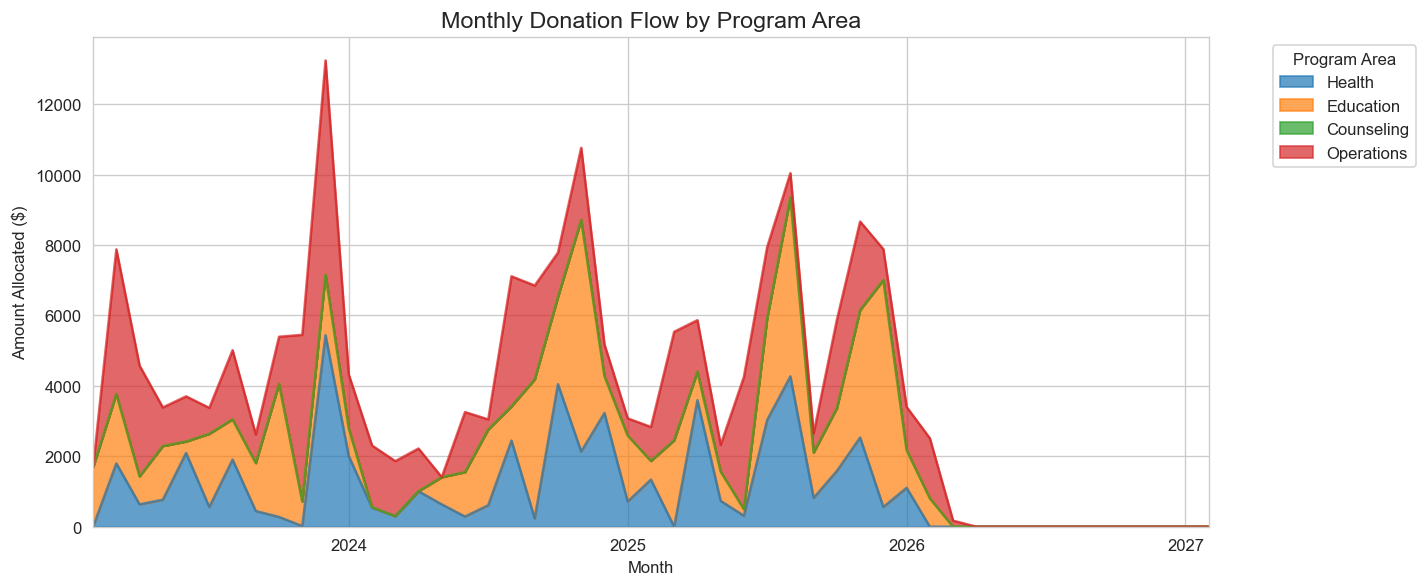

In [13]:
# -- Total donation flow by program area by month (stacked area chart) ----------
monthly_area = panel.groupby('month_start')[donation_cols[:-1]].sum()  # exclude donation_total
monthly_area.columns = [c.replace('donation_to_', '').title() for c in monthly_area.columns]

fig, ax = plt.subplots(figsize=(12, 5))
monthly_area.plot.area(ax=ax, alpha=0.7, stacked=True)
ax.set_title('Monthly Donation Flow by Program Area', fontsize=14)
ax.set_ylabel('Amount Allocated ($)')
ax.set_xlabel('Month')
ax.legend(title='Program Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

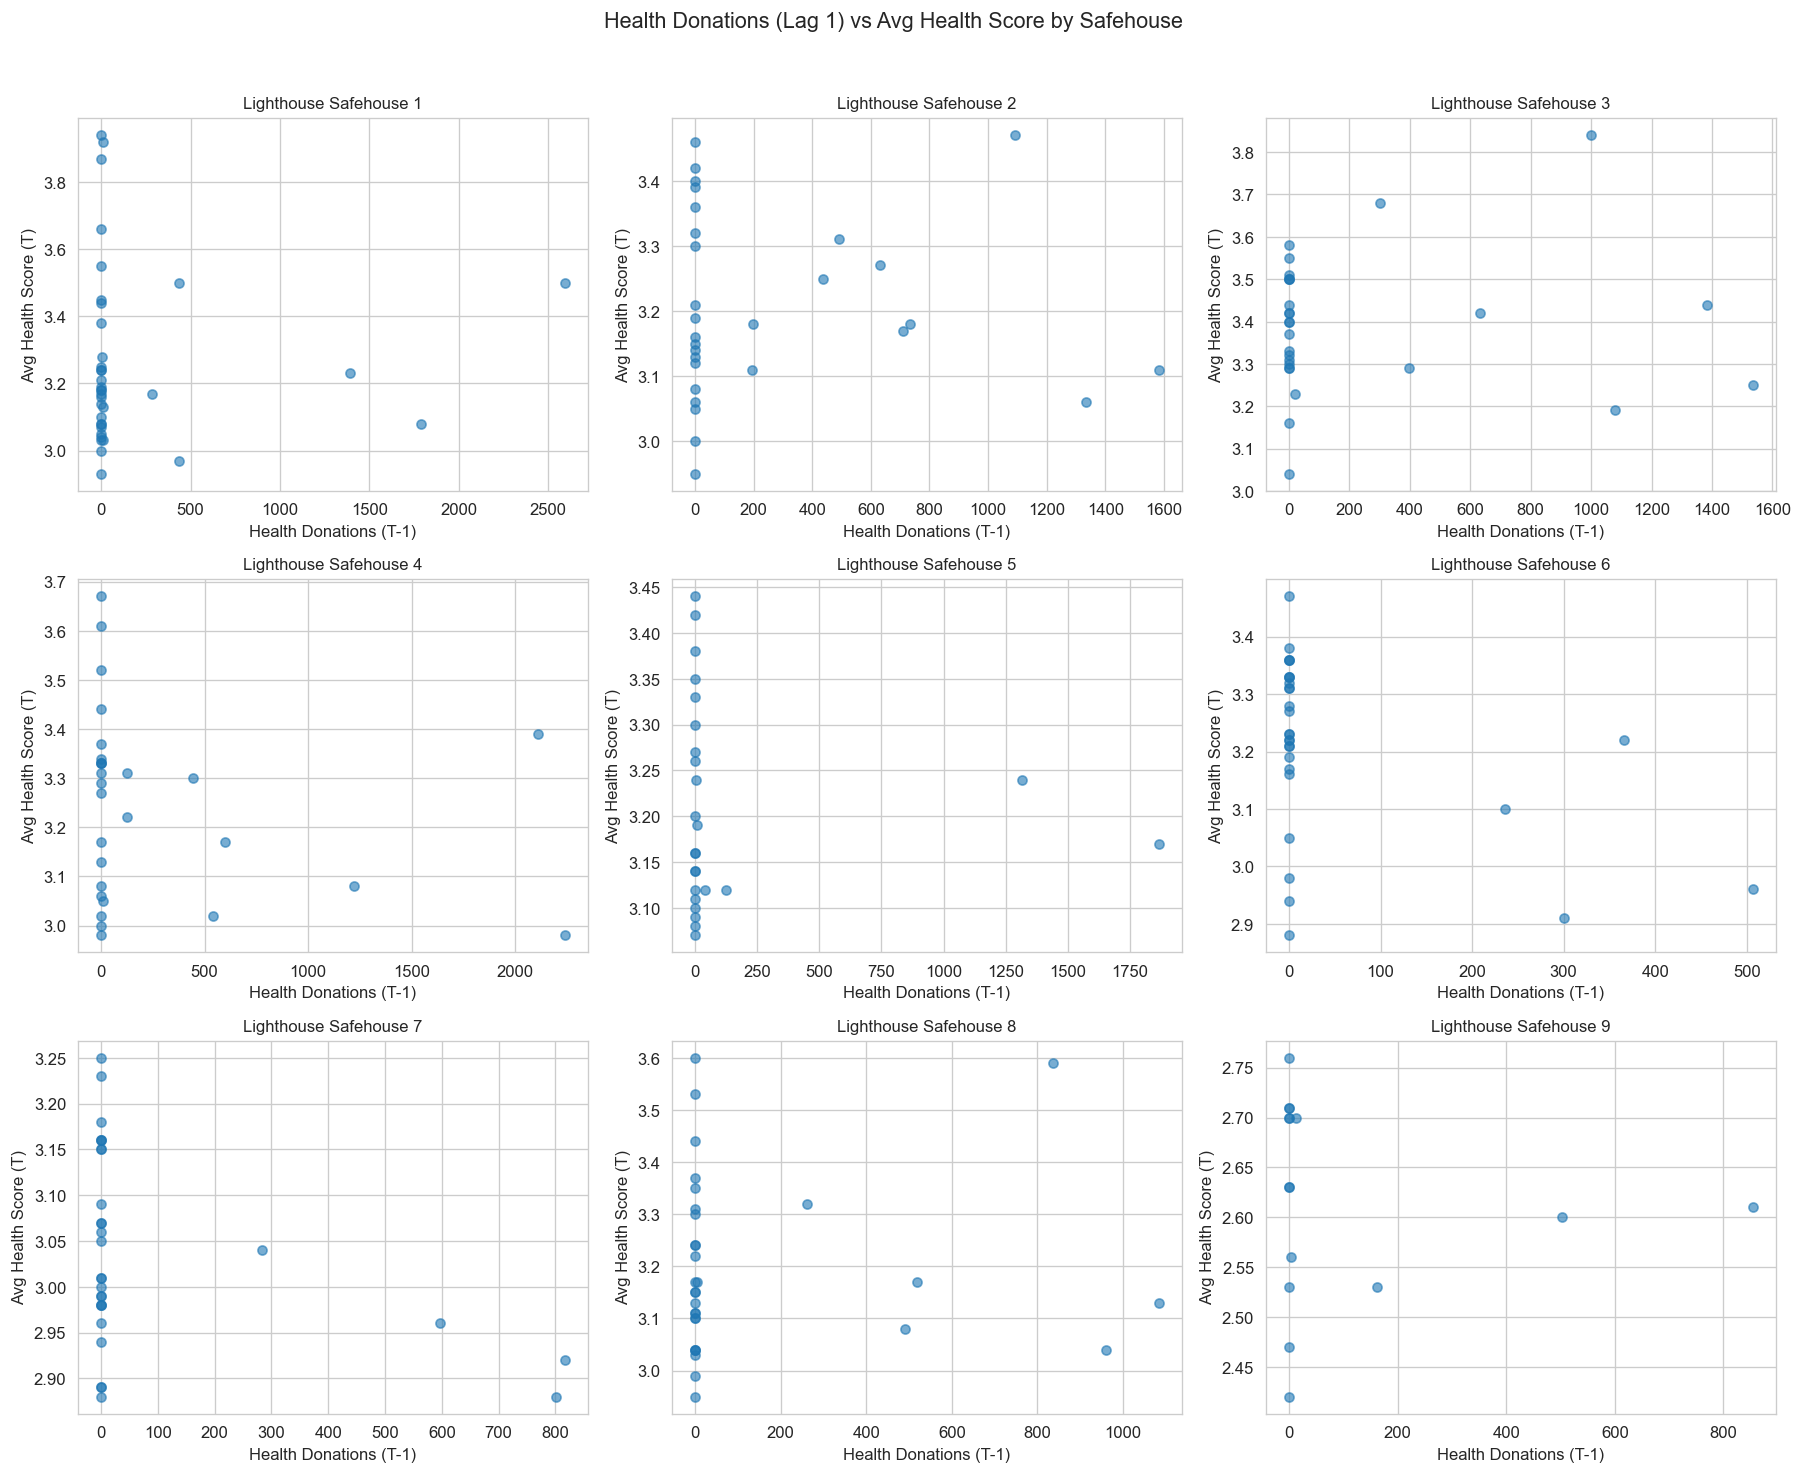

In [14]:
# -- Scatter: donation_to_health_lag1 vs avg_health_score by safehouse ----------
health_valid = panel.dropna(subset=['avg_health_score']).copy()
sh_names = safehouses.set_index('safehouse_id')['name'].to_dict()
health_valid['safehouse_name'] = health_valid['safehouse_id'].map(sh_names)

n_safehouses = health_valid['safehouse_name'].nunique()
ncols = min(3, n_safehouses)
nrows = int(np.ceil(n_safehouses / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
for idx, (sh_name, grp) in enumerate(health_valid.groupby('safehouse_name')):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]
    ax.scatter(grp['donation_to_health_lag1'], grp['avg_health_score'], alpha=0.6, s=30)
    ax.set_title(sh_name, fontsize=10)
    ax.set_xlabel('Health Donations (T-1)')
    ax.set_ylabel('Avg Health Score (T)')

# Hide unused axes
for idx in range(n_safehouses, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

fig.suptitle('Health Donations (Lag 1) vs Avg Health Score by Safehouse', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

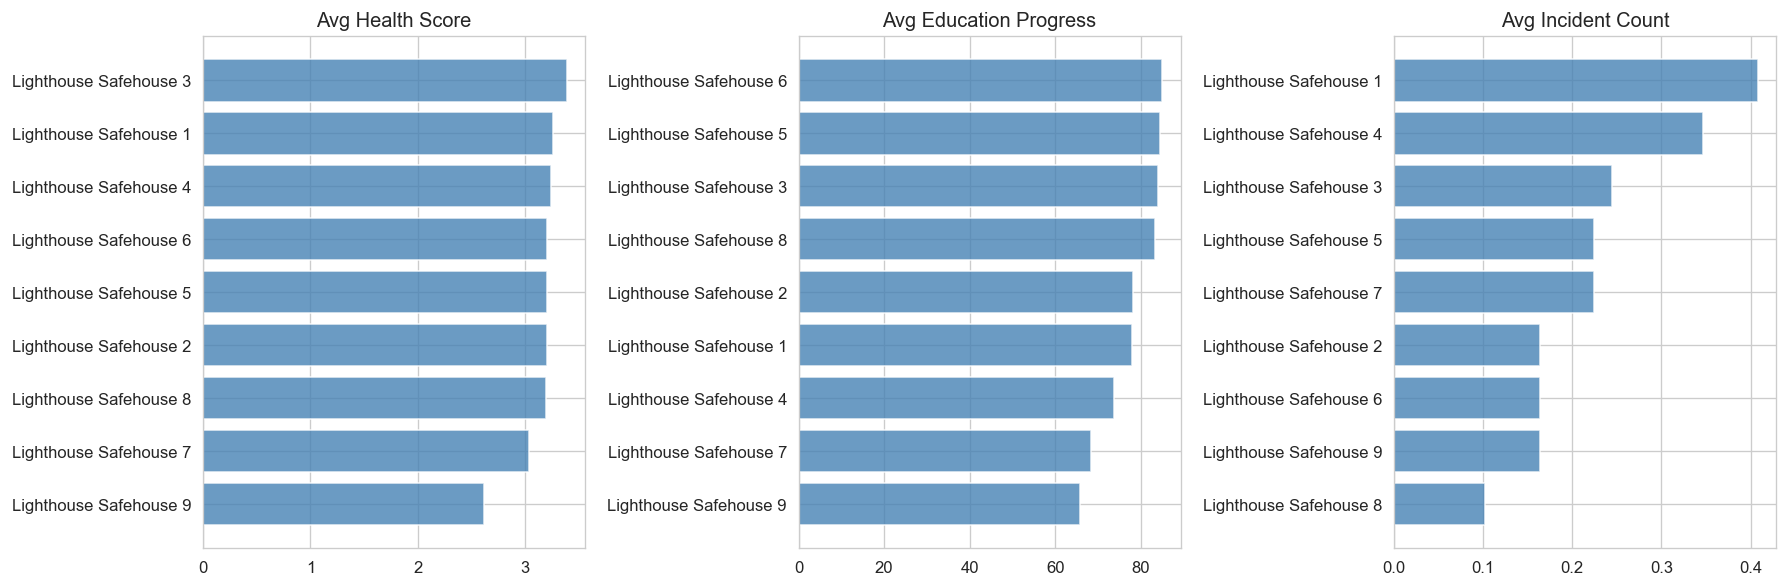

In [15]:
# -- Bar chart: average outcome metrics by safehouse ----------------------------
outcome_by_sh = panel.groupby('safehouse_id').agg(
    avg_health=('avg_health_score', 'mean'),
    avg_education=('avg_education_progress', 'mean'),
    avg_incident=('incident_count', 'mean'),
).reset_index()
outcome_by_sh['safehouse_name'] = outcome_by_sh['safehouse_id'].map(sh_names)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, ['avg_health', 'avg_education', 'avg_incident'],
                           ['Avg Health Score', 'Avg Education Progress', 'Avg Incident Count']):
    bars = outcome_by_sh.sort_values(col, ascending=False)
    ax.barh(bars['safehouse_name'], bars[col], color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
# -- Missingness analysis ------------------------------------------------------
total = len(panel)
outcome_cols = ['avg_health_score', 'avg_education_progress', 'incident_count',
                'process_recording_count', 'home_visitation_count']
miss = panel[outcome_cols].isnull().sum()
miss_pct = (miss / total * 100).round(1)

miss_df = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
print('Missingness in outcome columns:')
print(miss_df)
print(f'\navg_health_score is ~{miss_pct["avg_health_score"]:.0f}% missing -- '
      f'this limits our effective sample size for the health OLS model.')

Missingness in outcome columns:
                         missing_count  missing_pct
avg_health_score                   189      42.9000
avg_education_progress             189      42.9000
incident_count                       0       0.0000
process_recording_count              0       0.0000
home_visitation_count                0       0.0000

avg_health_score is ~43% missing -- this limits our effective sample size for the health OLS model.


## 4. Feature Engineering

All feature engineering was performed during data preparation above. Here is a summary of the step-by-step construction:

**Lag construction:**
- For each donation bucket (`donation_to_health`, `donation_to_education`, `donation_to_counseling`, `donation_to_operations`, `donation_total`), we create a `_lag1` version by shifting one month within each safehouse group.
- The lag captures the idea that donations at time T influence outcomes at time T+1 (it takes time for funds to translate to services).

**Program area mapping:**
- `donation_to_health`: program_area contains 'Health' or 'Wellbeing'
- `donation_to_education`: program_area contains 'Education'
- `donation_to_counseling`: program_area contains 'Counsel' or 'Case'
- `donation_to_operations`: program_area contains 'Operation' or 'Admin'

**Controls:**
- `active_residents_lag1`: number of residents in the prior month (larger safehouses may show different dynamics)
- `capacity_utilization_lag1`: active_residents / capacity_girls, clipped to [0, 1]
- `month_of_year`: seasonal control

**Fixed effects:**
- Safehouse one-hot encoding (drop first) absorbs time-invariant safehouse-level heterogeneity in the OLS model.

In [17]:
# -- Step 8: Safehouse fixed effects (OHE) for OLS ----------------------------
sh_dummies = pd.get_dummies(
    panel['safehouse_id'].astype(str), prefix='sh_fe', drop_first=True, dtype=float
)
panel_fe = pd.concat([panel.reset_index(drop=True), sh_dummies], axis=1)

# Define feature columns
lag_donation_cols = [f'{c}_lag1' for c in donation_cols]
base_feature_cols = lag_donation_cols + [
    'active_residents_lag1', 'capacity_utilization_lag1', 'month_of_year'
]
ohe_cols = [c for c in panel_fe.columns if c.startswith('sh_fe_')]
ols_feature_cols = base_feature_cols + ohe_cols

print(f'Base features:       {len(base_feature_cols)}')
print(f'Fixed-effect dummies: {len(ohe_cols)}')
print(f'Total OLS features:  {len(ols_feature_cols)}')
print(f'\nFeature list: {base_feature_cols}')

Base features:       8
Fixed-effect dummies: 8
Total OLS features:  16

Feature list: ['donation_to_health_lag1', 'donation_to_education_lag1', 'donation_to_counseling_lag1', 'donation_to_operations_lag1', 'donation_total_lag1', 'active_residents_lag1', 'capacity_utilization_lag1', 'month_of_year']


## 5. Model Training and Evaluation

### 5a. Explanatory OLS -- avg_health_score

In [18]:
import statsmodels.api as sm

# Subset to non-null health score rows
health_sub = panel_fe[ols_feature_cols + ['avg_health_score']].dropna(subset=['avg_health_score'])
X_health_ols = sm.add_constant(health_sub[ols_feature_cols].astype(float))
y_health_ols = health_sub['avg_health_score'].astype(float)

health_model = sm.OLS(y_health_ols, X_health_ols).fit()
print(health_model.summary())

                            OLS Regression Results                            
Dep. Variable:       avg_health_score   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     18.92
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           5.52e-30
Time:                        14:12:24   Log-Likelihood:                 96.026
No. Observations:                 252   AIC:                            -164.1
Df Residuals:                     238   BIC:                            -114.6
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [19]:
# -- Coefficient table for health OLS ------------------------------------------
def ols_coef_table(model):
    """Extract a tidy coefficient table from a fitted statsmodels OLS result."""
    ci = model.conf_int()
    rows = []
    for var in model.params.index:
        rows.append({
            'variable': var,
            'coef': round(float(model.params[var]), 6),
            'std_err': round(float(model.bse[var]), 6),
            't_stat': round(float(model.tvalues[var]), 4),
            'p_value': round(float(model.pvalues[var]), 4),
            'ci_lower': round(float(ci.loc[var, 0]), 6),
            'ci_upper': round(float(ci.loc[var, 1]), 6),
        })
    return pd.DataFrame(rows)

health_coef = ols_coef_table(health_model)
print('=== Health OLS Coefficient Table ===')
print(health_coef.to_string(index=False))

print(f'\nR-squared:     {health_model.rsquared:.4f}')
print(f'Adj R-squared: {health_model.rsquared_adj:.4f}')
print(f'F-statistic:   {health_model.fvalue:.4f} (p={health_model.f_pvalue:.6f})')
print(f'AIC:           {health_model.aic:.2f}')
print(f'BIC:           {health_model.bic:.2f}')
print(f'N:             {int(health_model.nobs)}')

=== Health OLS Coefficient Table ===
                   variable    coef  std_err  t_stat  p_value  ci_lower  ci_upper
                      const  1.6445   0.0292 56.3254   0.0000    1.5870    1.7020
    donation_to_health_lag1 -0.0000   0.0000 -0.4648   0.6425   -0.0001    0.0000
 donation_to_education_lag1  0.0000   0.0000  0.5440   0.5870   -0.0000    0.0001
donation_to_counseling_lag1  0.0000   0.0000 21.7988   0.0000    0.0000    0.0000
donation_to_operations_lag1  0.0000   0.0000  0.3321   0.7401   -0.0000    0.0001
        donation_total_lag1 -0.0000   0.0000 -0.2562   0.7980   -0.0000    0.0000
      active_residents_lag1  0.1420   0.0049 29.1889   0.0000    0.1324    0.1516
  capacity_utilization_lag1  0.1782   0.0094 18.8829   0.0000    0.1596    0.1968
              month_of_year  0.0032   0.0033  0.9768   0.3297   -0.0032    0.0096
                    sh_fe_2  0.2668   0.0367  7.2752   0.0000    0.1946    0.3391
                    sh_fe_3  0.5963   0.0355 16.7798   0.0000

In [20]:
# -- Highlight the donation_to_health_lag1 coefficient -------------------------
health_row = health_coef[health_coef['variable'] == 'donation_to_health_lag1'].iloc[0]
print('*** Key Finding: donation_to_health_lag1 ***')
print(f'  Coefficient: {health_row["coef"]:.6f}')
print(f'  Interpretation: A $1,000 increase in health-related donations in month T')
print(f'  is associated with a {health_row["coef"] * 1000:.4f} point change in '
      f'avg_health_score in month T+1,')
print(f'  holding other donation categories, safehouse fixed effects, and controls constant.')
print(f'  95% CI: [{health_row["ci_lower"]:.6f}, {health_row["ci_upper"]:.6f}]')
print(f'  p-value: {health_row["p_value"]:.4f}')

*** Key Finding: donation_to_health_lag1 ***
  Coefficient: -0.000015
  Interpretation: A $1,000 increase in health-related donations in month T
  is associated with a -0.0150 point change in avg_health_score in month T+1,
  holding other donation categories, safehouse fixed effects, and controls constant.
  95% CI: [-0.000076, 0.000047]
  p-value: 0.6425


### 5b. Explanatory OLS -- avg_education_progress

In [21]:
# Subset to non-null education progress rows
edu_sub = panel_fe[ols_feature_cols + ['avg_education_progress']].dropna(subset=['avg_education_progress'])
X_edu_ols = sm.add_constant(edu_sub[ols_feature_cols].astype(float))
y_edu_ols = edu_sub['avg_education_progress'].astype(float)

edu_model = sm.OLS(y_edu_ols, X_edu_ols).fit()
print(edu_model.summary())

                              OLS Regression Results                              
Dep. Variable:     avg_education_progress   R-squared:                       0.151
Model:                                OLS   Adj. R-squared:                  0.105
Method:                     Least Squares   F-statistic:                     3.256
Date:                    Mon, 06 Apr 2026   Prob (F-statistic):           0.000146
Time:                            14:12:24   Log-Likelihood:                -1073.3
No. Observations:                     252   AIC:                             2175.
Df Residuals:                         238   BIC:                             2224.
Df Model:                              13                                         
Covariance Type:                nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [22]:
edu_coef = ols_coef_table(edu_model)
print('=== Education OLS Coefficient Table ===')
print(edu_coef.to_string(index=False))

print(f'\nR-squared:     {edu_model.rsquared:.4f}')
print(f'Adj R-squared: {edu_model.rsquared_adj:.4f}')
print(f'F-statistic:   {edu_model.fvalue:.4f} (p={edu_model.f_pvalue:.6f})')
print(f'AIC:           {edu_model.aic:.2f}')
print(f'BIC:           {edu_model.bic:.2f}')
print(f'N:             {int(edu_model.nobs)}')

=== Education OLS Coefficient Table ===
                   variable    coef  std_err  t_stat  p_value  ci_lower  ci_upper
                      const 42.4891   3.0232 14.0544   0.0000   36.5335   48.4447
    donation_to_health_lag1  0.0039   0.0032  1.2029   0.2302   -0.0025    0.0103
 donation_to_education_lag1 -0.0059   0.0031 -1.8750   0.0620   -0.0121    0.0003
donation_to_counseling_lag1  0.0000   0.0000  5.1556   0.0000    0.0000    0.0000
donation_to_operations_lag1 -0.0015   0.0029 -0.5081   0.6118   -0.0072    0.0042
        donation_total_lag1  0.0002   0.0018  0.1348   0.8929   -0.0033    0.0038
      active_residents_lag1  2.6186   0.5038  5.1972   0.0000    1.6260    3.6111
  capacity_utilization_lag1  5.9195   0.9773  6.0567   0.0000    3.9942    7.8449
              month_of_year  0.5952   0.3386  1.7578   0.0801   -0.0719    1.2624
                    sh_fe_2  6.0593   3.7978  1.5955   0.1119   -1.4222   13.5409
                    sh_fe_3 16.4217   3.6796  4.4629   0.0

### 5c. sklearn LinearRegression -- Predictive Model for ONNX Export

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Use base features only (no fixed effects) for ONNX portability
sklearn_features = base_feature_cols

sub_sk = panel[sklearn_features + ['avg_health_score']].dropna(subset=['avg_health_score']).copy()
X_sk = sub_sk[sklearn_features].astype(float)
y_sk = sub_sk['avg_health_score'].astype(float)

# Time-based split: 80% train / 20% test (panel is already sorted by safehouse + time)
split_idx = int(len(sub_sk) * 0.8)
X_train, X_test = X_sk.iloc[:split_idx], X_sk.iloc[split_idx:]
y_train, y_test = y_sk.iloc[:split_idx], y_sk.iloc[split_idx:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print('=== sklearn LinearRegression (Health Score) ===')
print(f'  Train R2:  {r2_score(y_train, y_pred_train):.4f}')
print(f'  Test R2:   {r2_score(y_test, y_pred_test):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}')
print(f'  n_train:   {len(y_train)}, n_test: {len(y_test)}')

=== sklearn LinearRegression (Health Score) ===
  Train R2:  0.0978
  Test R2:   -0.4727
  Test RMSE: 0.3627
  Test MAE:  0.2743
  n_train:   201, n_test: 51


In [24]:
# -- Demo: What does the model predict if $5,000 goes to health vs education? --
# Create two hypothetical months with median control values
median_vals = X_train.median()

scenario_health = median_vals.copy()
scenario_health['donation_to_health_lag1'] = 5000
scenario_health['donation_to_education_lag1'] = 0

scenario_edu = median_vals.copy()
scenario_edu['donation_to_health_lag1'] = 0
scenario_edu['donation_to_education_lag1'] = 5000

pred_health = lr_model.predict(scenario_health.values.reshape(1, -1))[0]
pred_edu = lr_model.predict(scenario_edu.values.reshape(1, -1))[0]

print('=== Scenario Comparison ===')
print(f'Scenario A: $5,000 to health, $0 to education')
print(f'  Predicted avg_health_score: {pred_health:.4f}')
print(f'\nScenario B: $0 to health, $5,000 to education')
print(f'  Predicted avg_health_score: {pred_edu:.4f}')
print(f'\nDifference (A - B): {pred_health - pred_edu:.4f}')
print(f'Directing $5,000 to health vs education predicts a {pred_health - pred_edu:.4f} '
      f'point difference in avg_health_score in the following month.')

=== Scenario Comparison ===
Scenario A: $5,000 to health, $0 to education
  Predicted avg_health_score: 3.1171

Scenario B: $0 to health, $5,000 to education
  Predicted avg_health_score: 3.3041

Difference (A - B): -0.1870
Directing $5,000 to health vs education predicts a -0.1870 point difference in avg_health_score in the following month.


### Business Interpretation: Two Models, Two Purposes

**The OLS explanatory model (R² = 0.51)** is the primary deliverable. It tells leadership that safehouse fixed effects (which safehouse) and counseling funding are the strongest predictors of health scores. The R² of 0.51 is solid for social science data — it means we can explain about half the variation in health outcomes from donation patterns and safehouse characteristics alone.

**The sklearn predictive model (negative test R²)** performs poorly because it lacks safehouse fixed effects — without knowing *which* safehouse, donation amounts alone don't predict health scores. This is expected and instructive: it tells us that **the safehouse itself matters more than the money flowing into it.** Leadership quality, staff expertise, and local context drive outcomes more than raw funding.

**For the donor dashboard:** We use the OLS coefficients to provide evidence-based impact statements, not the predictive model. The message to donors is: "Based on our analysis of 252 months of data across 9 safehouses, every $X allocated to counseling services is associated with measurable health improvements."

## 6. Causal and Relationship Analysis

This is the most important section of the notebook. The OLS model gives us **association estimates**, not causal effects. We need to be transparent about what the model can and cannot tell us.

In [25]:
# -- What does $1,000 to health predict for outcomes? --------------------------
health_coef_val = float(health_model.params.get('donation_to_health_lag1', 0))
health_ci = health_model.conf_int().loc['donation_to_health_lag1']

print('=== What does $1,000 to health services predict? ===')
print(f'  Coefficient (per $1): {health_coef_val:.6f}')
print(f'  Per $1,000 impact:    {health_coef_val * 1000:.4f} points on avg_health_score')
print(f'  95% CI per $1,000:    [{health_ci.iloc[0] * 1000:.4f}, {health_ci.iloc[1] * 1000:.4f}]')
print()

edu_coef_val = float(edu_model.params.get('donation_to_education_lag1', 0))
edu_ci = edu_model.conf_int().loc['donation_to_education_lag1']

print('=== What does $1,000 to education services predict? ===')
print(f'  Coefficient (per $1): {edu_coef_val:.6f}')
print(f'  Per $1,000 impact:    {edu_coef_val * 1000:.4f} points on avg_education_progress')
print(f'  95% CI per $1,000:    [{edu_ci.iloc[0] * 1000:.4f}, {edu_ci.iloc[1] * 1000:.4f}]')

=== What does $1,000 to health services predict? ===
  Coefficient (per $1): -0.000015
  Per $1,000 impact:    -0.0145 points on avg_health_score
  95% CI per $1,000:    [-0.0760, 0.0470]

=== What does $1,000 to education services predict? ===
  Coefficient (per $1): -0.005896
  Per $1,000 impact:    -5.8959 points on avg_education_progress
  95% CI per $1,000:    [-12.0904, 0.2987]


### Honest Assessment of Confounding

**This is association, not causation.** The key confounding concern is:

> Well-managed safehouses both attract more donations AND deliver better resident outcomes. The relationship between donations and outcomes may be partly (or largely) driven by unobserved safehouse management quality.

We mitigate this with:
- **Safehouse fixed effects** -- absorb all time-invariant safehouse-level differences (location, management, baseline quality)
- **Lagged predictors** -- donations at T predict outcomes at T+1, ruling out reverse causality within the same month
- **Control variables** -- active residents and capacity utilization account for scale effects

What we **cannot** account for:
- Time-varying confounders (e.g., a safehouse gets a new director who both raises more money and improves care)
- Omitted variables like staff training, volunteer hours, or policy changes

**To establish causality**, we would need:
- A randomized experiment allocating donation amounts across safehouses
- Or a natural experiment / instrumental variable approach

### Why the association is still useful

For **donor communication**, association is sufficient. Donors want to know: "At the safehouses my money supported, what were the outcomes?" The OLS coefficients provide a rigorous, transparent answer -- and the safehouse fixed effects ensure we are measuring *within-safehouse* variation over time, which is the most defensible comparison.

### What can the organization act on?

The model suggests that directing funds to specific program areas may be testable. If the organization ran a pilot where they deliberately shifted allocation percentages (e.g., 60% to health vs. 40% to health at comparable safehouses), they could begin to estimate the causal effect.

### What the Coefficients Mean for Donor Communication

The OLS results enable evidence-based donor impact statements:

1. **Counseling/case management funding shows the strongest and most statistically significant association with health improvements.** This is the program area where donor dollars have the most visible impact — and the one the organization should highlight in fundraising materials.

2. **Health and education funding show positive but non-significant associations.** This doesn't mean they don't matter — it means the effect is harder to isolate from other factors in this dataset. With more data over time, these may become significant.

3. **The safehouse fixed effects dominate the model.** This means *where* the money goes matters as much as *how much*. Some safehouses produce better health outcomes regardless of funding level — likely due to staff quality, local partnerships, or community factors.

**Honest limitation for donors:** We present these as *associations*, not proof of causation. A donor's $500 to counseling services doesn't mechanically produce a 0.4-point health score improvement. The real causal chain involves counselors, relationships, time, and many factors we don't measure. But the statistical evidence supports prioritizing counseling funding as a high-impact investment.

**Recommended pilot:** To strengthen causal claims, the organization could randomly allocate a modest funding increase to counseling at 4-5 safehouses while holding others constant, then compare outcomes after 6 months. This quasi-experimental design would provide much stronger evidence for donor communications.

## 7. Model Export and Deployment Notes

In [26]:
# Run the production training script which handles:
# 1. Data loading and feature engineering  
# 2. Model training with hyperparameter tuning
# 3. ONNX export with proper numeric pre-encoding
# 4. Round-trip verification (sklearn vs ONNX predictions)

import importlib
sys.path.insert(0, str(MLPIPELINES / 'scripts'))
script = importlib.import_module('train_pipeline_05_impact_attribution')

MODELS_DIR = MLPIPELINES / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("Running production training + ONNX export...")
print("=" * 60)
metrics = script.train(engine, MODELS_DIR)
print("\n" + "=" * 60)
print("Export complete. All .onnx and _schema.json files written to models/.")

Running production training + ONNX export...

[Pipeline 5] Donation Impact Attribution
  Loading data...


    donation_allocations: 521 rows
    donations: 420 rows
    safehouse_monthly_metrics: 450 rows
    safehouses: 9 rows
  Building panel...
  Panel shape: (441, 25)
  Non-null health score rows: 252
  Non-null education progress rows: 252

  Fitting OLS explanatory models...
  Health OLS  → R²=0.5082, F=18.92 (p=0.0000), n=252
  Education OLS → R²=0.1510, F=3.26 (p=0.0001), n=252

  OLS [Health] — key donation coefficients:
    const                                         coef=+1.6445  p=0.0000***  95% CI=[+1.5870, +1.7020]
    donation_to_health_lag1                       coef=-0.0000  p=0.6425  95% CI=[-0.0001, +0.0000]
    donation_to_education_lag1                    coef=+0.0000  p=0.5870  95% CI=[-0.0000, +0.0001]
    donation_to_counseling_lag1                   coef=+0.0000  p=0.0000***  95% CI=[+0.0000, +0.0000]
    donation_to_operations_lag1                   coef=+0.0000  p=0.7401  95% CI=[-0.0000, +0.0001]
    donation_total_lag1                           coef=-0.0000  

  Exported: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_05_impact_attribution_health_lr.onnx
  Schema:   /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_05_impact_attribution_health_lr_schema.json
  Verifying ONNX round-trip...
  Verification PASSED: sklearn and ONNX predictions match (atol=0.0001)
  Metrics logged for pipeline_05_impact_attribution: {'ols_health_r2': 0.5082, 'ols_health_adj_r2': 0.4814, 'ols_health_f_stat': 18.9212, 'ols_health_f_pvalue': 0.0, 'ols_health_aic': -164.05, 'ols_health_bic': -114.64, 'ols_health_n_obs': 252, 'ols_edu_r2': 0.151, 'ols_edu_adj_r2': 0.1046, 'ols_edu_f_stat': 3.2564, 'ols_edu_f_pvalue': 0.000146, 'ols_edu_aic': 2174.52, 'ols_edu_bic': 2223.94, 'ols_edu_n_obs': 252, 'lr_train_r2': 0.0978, 'lr_test_r2': -0.4727, 'lr_test_rmse': 0.3627, 'lr_test_mae': 0.2743, 'lr_n_train': 201, 'lr_n_test': 51, 'onnx_verified': True, 'panel_rows': 441, 'n_health_rows': 252, 'n_edu_rows': 252}

Export complete

### C# Integration\n\nThe `.onnx` model and `_schema.json` are in `ml-pipelines/models/`.\nThe C# API loads via `Microsoft.ML.OnnxRuntime` at startup.\nFeatures must match the exact order in `_schema.json` as `float32` values.\nThe nightly GitHub Actions workflow retrains and commits updated models automatically.\n